In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

<Axes: >

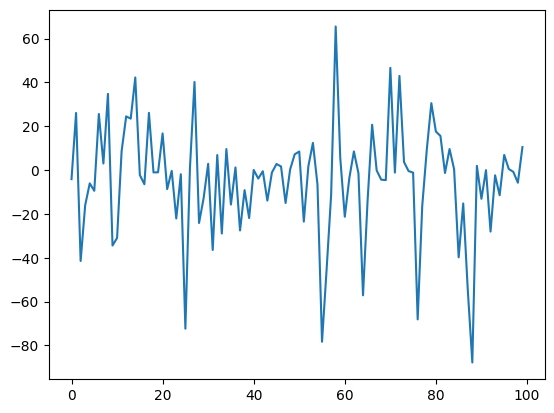

In [27]:
arr = np.random.rand(100) * 100
new_arr = np.array([])

for item in arr:
    item = item*np.random.rand()*np.sin(item)
    new_arr = np.append(new_arr, item)

new_arr = pd.Series(new_arr)
new_arr.plot()

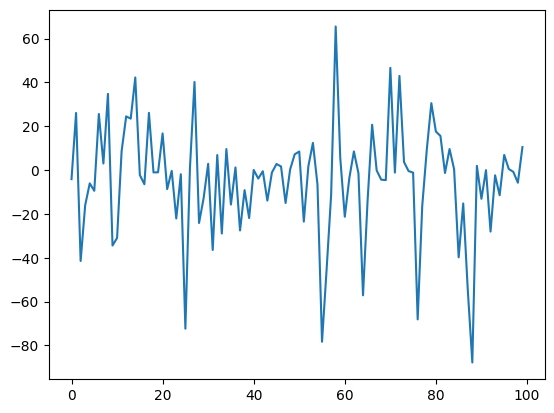

In [29]:
plt.plot(new_arr)

[-6.498003091964791, -10.46692222731423, -21.177190951833754, -10.502181477283173, 3.3760783672987906, 6.395842598106377, 21.142764034521562, 1.1333966264764446, -10.187385921378512, -18.90103285401425, 0.7371048411756327, 18.88925169418798, 30.098459984361202, 21.183611352775884, 11.20308746649303, 5.817728261946278, 6.212829434884374, 8.031372649012567, 4.903174086662696, 2.3649096077943508, 2.586786784778255, -10.355482698631155, -8.088595061889338, -32.096542112849285, -24.43681124612212, -10.410268205125488, 5.667211403344926, 1.0873935483049781, -11.351057283105824, -15.45833898696191, -8.883810069637386, -19.49040324912697, -4.141123521129819, -11.671433507593633, -1.619069130767998, -14.000521353398632, -11.814827962351222, -19.515884624088923, -10.312016873404254, -8.546574974593458, -1.4263598701087952, -6.089178210210406, -5.16815581412722, -4.063631317374378, 1.1298371444051436, -3.50419628600312, -4.326127771999214, -2.4768058032298312, 5.35199057516191, -2.59103970418674,

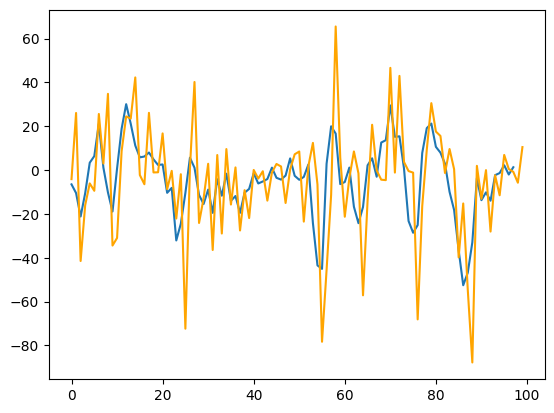

In [31]:
data = new_arr.tolist()
window_size = 3

sma = []

for i in range(len(data) - window_size + 1):
    
    window = data[i : i + window_size]
    
    average = sum(window) / window_size
    
    sma.append(average)

print(sma)
plt.plot(sma)
plt.plot(new_arr, color='orange')

Original Length: 100
SMA Length: 100


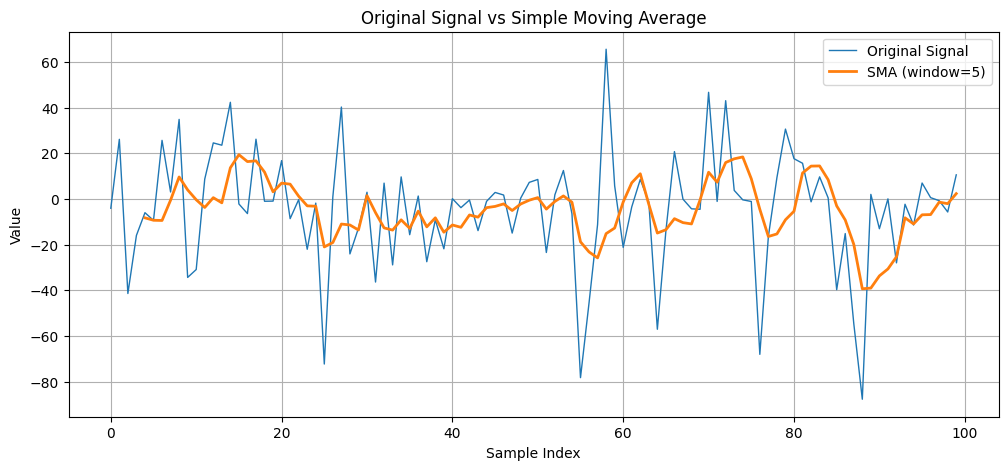

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Example signal
new_arr = np.array(new_arr)

window_size = 5

# Compute SMA
sma = []

for i in range(len(new_arr) - window_size + 1):
    window = new_arr[i:i + window_size]
    average = np.mean(window)
    sma.append(average)

# Pad beginning with NaN so lengths match
sma_padded = [np.nan] * (window_size - 1) + sma

# Check lengths
print("Original Length:", len(new_arr))
print("SMA Length:", len(sma_padded))

# Plot
plt.figure(figsize=(12, 5))

plt.plot(new_arr, label='Original Signal', linewidth=1)

plt.plot(
    sma_padded,
    label=f'SMA (window={window_size})',
    linewidth=2
)

plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.title("Original Signal vs Simple Moving Average")
plt.legend()
plt.grid(True)

plt.show()

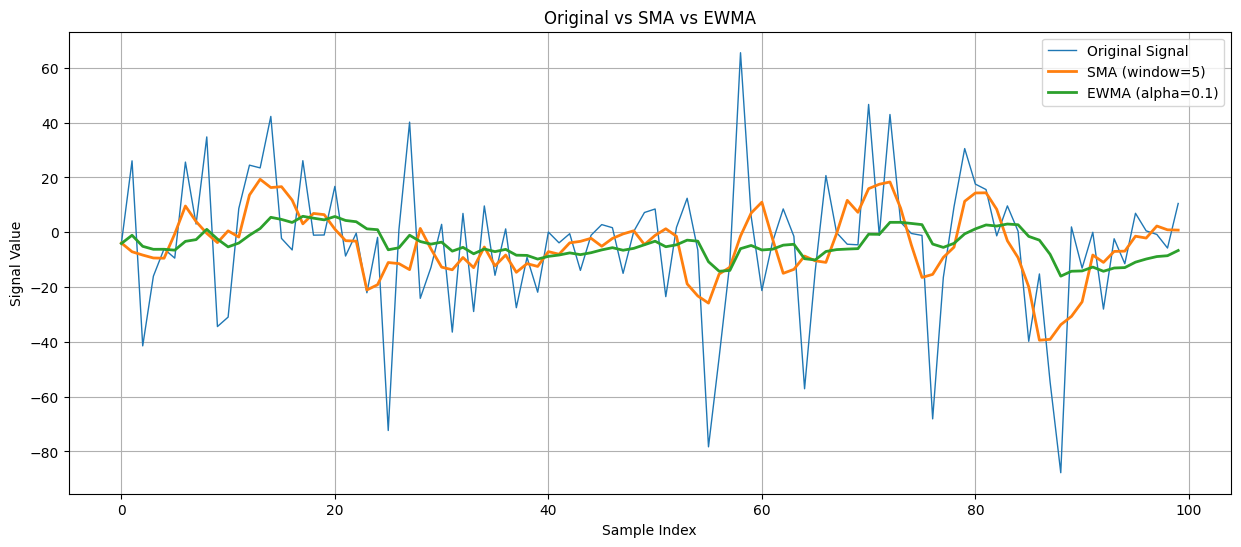

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Your signal
new_arr = np.array(new_arr)

# =========================
# SIMPLE MOVING AVERAGE
# =========================

window_size = 5

sma = np.convolve(
    new_arr,
    np.ones(window_size) / window_size,
    mode='same'
)

# =========================
# EXPONENTIALLY WEIGHTED MOVING AVERAGE
# =========================

alpha = 0.1  # Current data weight

ewma = np.zeros(len(new_arr))

# Initialize first value
ewma[0] = new_arr[0]

for i in range(1, len(new_arr)):
    ewma[i] = alpha * new_arr[i] + (1 - alpha) * ewma[i - 1]

# =========================
# PLOTTING
# =========================

plt.figure(figsize=(15, 6))

plt.plot(
    new_arr,
    label='Original Signal',
    linewidth=1
)

plt.plot(
    sma,
    label=f'SMA (window={window_size})',
    linewidth=2
)

plt.plot(
    ewma,
    label=f'EWMA (alpha={alpha})',
    linewidth=2
)

plt.title("Original vs SMA vs EWMA")
plt.xlabel("Sample Index")
plt.ylabel("Signal Value")

plt.legend()
plt.grid(True)

plt.show()

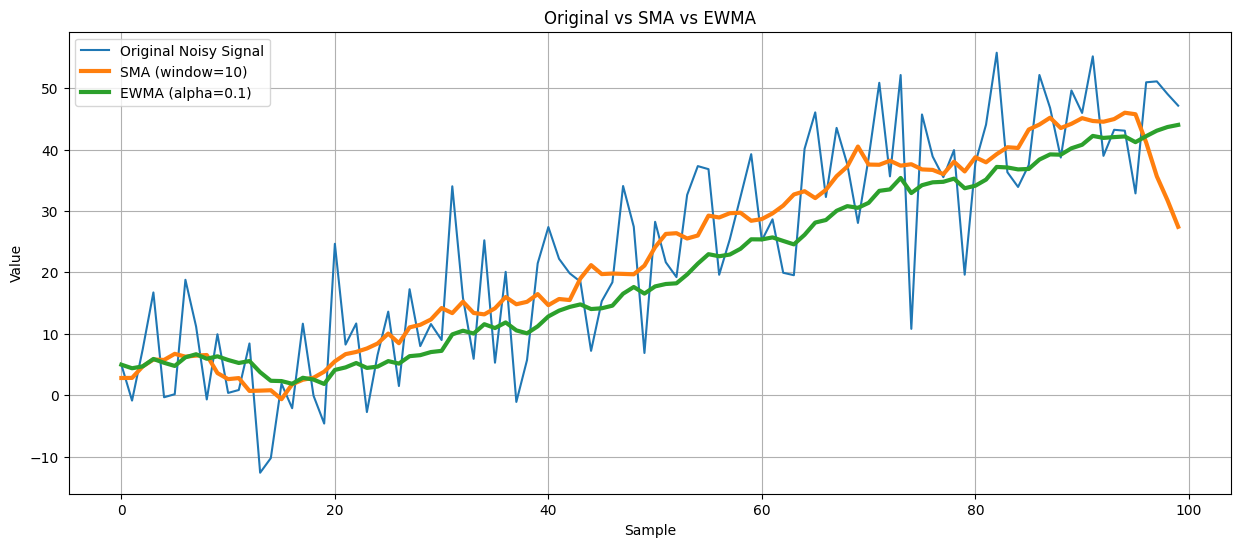

In [ ]:
# NOISY INCREASING SIGNAL

import numpy as np
import matplotlib.pyplot as plt

# ==================================
# Generate Noisy Increasing Signal
# ==================================

np.random.seed(42)

x = np.arange(100)

trend = x * 0.5

noise = np.random.normal(
    loc=0,
    scale=10,
    size=len(x)
)

new_arr = trend + noise

# ==================================
# SMA
# ==================================

window_size = 10

# Simple Moving Average
sma = np.convolve(
    new_arr,
    np.ones(window_size)/window_size,
    mode='same'
)

# ==================================
# EWMA  ( Explnential Weighted Moving Average )
# ==================================

alpha = 0.1

ewma = np.zeros(len(new_arr))

ewma[0] = new_arr[0]

for i in range(1, len(new_arr)):               
    ewma[i] = ( 
        alpha * new_arr[i]
        + (1 - alpha) * ewma[i-1]
    )

# ==================================
# Plot
# ==================================

plt.figure(figsize=(15,6))

plt.plot(
    new_arr,
    label="Original Noisy Signal"
)

plt.plot(
    sma,
    linewidth=3,
    label=f"SMA (window={window_size})"
)

plt.plot(
    ewma,
    linewidth=3,
    label=f"EWMA (alpha={alpha})"
)

plt.title("Original vs SMA vs EWMA")

plt.xlabel("Sample")

plt.ylabel("Value")

plt.grid(True)

plt.legend()

plt.show()